# **ADCP Data preprocessing**

<span style="color:red">This code was last tested on February 13, 2026, and is running without issues.</span>


**PURPOSE:** Open ADCP Data and perform the **second step** for preprocessing it in Python before synchronizing with the MicroCTD data.

This code will generate the pickle files: ADCP_totaltime.pkl, ADCP_totallevel.pkl,  ADCP_totaldepth.pkl, and ADCP_totalu.pkl.  It will also generate: **ADCP_selectdata.pkl**, as well as the corresponding files for each of the 3 distinct parts of the campaign: **drift**, **jetties**, and **transect**. Also genetares the pickle files: **'lon_dat_cast.pkl'** and **'lat_dat_cast.pkl'** and the **casts_detailed_map.png** with the detailed location of each cast on the map. 

__________________________________________________________________________________________  

**Input files:**  

ADCP_data1_ASC.TXT  
ADCP_data2_ASC.TXT  
ADCP_data3_ASC.TXT  
ADCP_data4_ASC.TXT  
ADCP_data5_ASC.TXT  

on path: = "/Users/deboragadelha/Jupyter/barros_et_al_2026/input_dir/ADCP_data/"

carta2101completa.tif  
satelitemap.tif  

on path: = "/Users/deboragadelha/Jupyter/barros_et_al_2026/input_dir/image_data/"  

  
**Output files:** 

ADCP_totaldata.pkl  
ADCP_totaltime.pkl  
ADCP_totallevel.pkl  
ADCP_totaldepth.pkl  
ADCP_totalu.pkl  
lon_dat_cast.pkl  
lat_dat_cast.pkl
ADCP_selectdata.pkl  
ADCP_data_drift.pkl  
ADCP_data_jetties.pkl  
ADCP_data_transect.pkl  
perf_adcp_depth.pkl

on path: = "/Users/deboragadelha/Jupyter/barros_et_al_2026/output_data/processed_data/"  


casts_map.png  
casts_detailed_map.png  
casts_satellitemapzoom.png  
casts_satellitemapfull.png  
casts_satellitemapfull_nolabel.png  


on path: = "/Users/deboragadelha/Jupyter/barros_et_al_2026/output_data/processed_image/"  
__________________________________________________________________________________________

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dateutil.parser import parse
import rasterio
import rasterio.plot as rplot
from IPython import display
import time as pytime
import pickle
import datetime
import scipy.io as scio
import os
os.getcwd()

from datetime import timedelta

# scipy.io.loadmat

Within this fieldwork, three distinct surveys were conducted. First, a drift was carried out along the thalweg, from inside the inlet to offshore. Then, MicroCTD data were collected at three different locations within the plume, near the jetties. Lastly, a transect was performed in front of the pilot station, with five sampling stations.

## Identifying each file corresponding to the three distinct internal surveys:

ADCP_data1_ASC.TXT = drift along the thalweg - Drift data  

ADCP_data2_ASC.TXT = Station 1 near the jetties (plume)  - Jetties data  
ADCP_data3_ASC.TXT = Station 2 near the jetties (plume)  - Jetties data  
ADCP_data4_ASC.TXT = Station 3 near the jetties (plume)  - Jetties data  

ADCP_data5_ASC.TXT = 5 stations over the transect  - Transect data

In [2]:
#open the files with the ADCP data:
path_ADCP = "/Users/deboragadelha/Jupyter/barros_et_al_2026/input_dir/ADCP_data/"
file1 = "ADCP_data1_ASC.TXT"
file2 = "ADCP_data2_ASC.TXT"
file3 = "ADCP_data3_ASC.TXT"
file4 = "ADCP_data4_ASC.TXT"
file5 = "ADCP_data5_ASC.TXT"

In [3]:
#creating a list with all the files:

files = [file1, file2, file3, file4, file5]

ADCPdata = []

for name in files:
    with open(os.path.join(path_ADCP, name)) as io:
        ADCPdata.extend(io.read().splitlines())

In [4]:
len(ADCPdata)


21570

In [5]:
output_data = '../output_dir/processed_data'
output_image = '../output_dir/processed_image'

os.makedirs(output_data, exist_ok=True)
os.makedirs(output_image, exist_ok=True)

# Save the pickle on the right folder:
with open(os.path.join(output_data, 'ADCP_totaldata.pkl'), 'wb') as io:
        pickle.dump(ADCPdata, io)





In [6]:
latitude = []
longitude = []
adcp_depth = []
adcp_levels = []
adcp_time = []
adcp_u = []
adcp_v = []
rea = []

for d in ADCPdata[1:]: # ???? --> 
    dq = d.split()
    adcp_time.append(mdates.num2date(float(dq[1])/(24*3600)))   # According to the manual... it's in seconds since 1/1/1970.
    longitude.append(float(dq[2]))
    latitude.append(float(dq[3]))
    adcp_depth.append(float(dq[4]))
    
    adcp_levels = [float(x) for x in dq[8].split(',')] # just need 1x
    
    p_rea = [float(x) for x in dq[9].split(',')]
    p_vel_u = [float(x) for x in dq[10].split(',')]
    p_vel_v = [float(x) for x in dq[11].split(',')]
    
    rea.append(p_rea)
    adcp_u.append(p_vel_u)
    adcp_v.append(p_vel_v)
    

# convert from list to arrays... in order to be able to do slicing later 
adcp_time = np.array(adcp_time)
longitude = np.array(longitude)
latitude = np.array(latitude)
adcp_depth = np.array(adcp_depth)
adcp_levels = np.array(adcp_levels)
rea = np.array(rea)
adcp_u = np.array(adcp_u)
adcp_v = np.array(adcp_v)

# substitute bad data by nan
adcp_depth[adcp_depth == -32768] = np.nan
rea[rea == -32768] = np.nan
adcp_u[adcp_u == -32768] = np.nan
adcp_v[adcp_v == -32768] = np.nan    

In [7]:
hdr = 'adcp_time, longitude, latitude, adcp_depth, adcp_levels, rea, adcp_u, adcp_v'

junta = [hdr, adcp_time, longitude, latitude, adcp_depth, adcp_levels, rea, adcp_u, adcp_v]

with open(os.path.join(output_data, 'adcp_rdz.pkl'), 'wb') as io:
    pickle.dump(junta, io)

In [8]:
adcp_time_n = mdates.date2num(adcp_time)
#still using "geral" data from ADCP 
#to change de MCTD_time from datetime to julian:

In [9]:
# Dictionary with file names and corresponding variables
adcp_data_dic = {
    'ADCP_totaltime.pkl': adcp_time,
    'ADCP_totallevel.pkl': adcp_levels,
    'ADCP_totaldepth.pkl': adcp_depth,
    'ADCP_totalu.pkl': adcp_u
}

# Loop to save all files:
for file_name, variavel in adcp_data_dic.items():
    with open(os.path.join(output_data, file_name), 'wb') as f:
        pickle.dump(variavel, f)


In [10]:
print(adcp_levels)

[ 1.11  1.36  1.61  1.86  2.11  2.36  2.61  2.86  3.11  3.36  3.61  3.86
  4.11  4.36  4.61  4.86  5.11  5.36  5.61  5.86  6.11  6.36  6.61  6.86
  7.11  7.36  7.61  7.86  8.11  8.36  8.61  8.86  9.11  9.36  9.61  9.86
 10.11 10.36 10.61 10.86 11.11 11.36 11.61 11.86 12.11 12.36 12.61 12.86
 13.11 13.36 13.61 13.86 14.11 14.36 14.61 14.86 15.11 15.36 15.61 15.86
 16.11 16.36 16.61 16.86 17.11 17.36 17.61 17.86 18.11 18.36 18.61 18.86
 19.11 19.36 19.61 19.86 20.11 20.36 20.61 20.86 21.11 21.36 21.61 21.86
 22.11 22.36 22.61 22.86 23.11 23.36 23.61 23.86 24.11 24.36 24.61 24.86
 25.11 25.36 25.61 25.86 26.11 26.36 26.61 26.86 27.11 27.36 27.61 27.86
 28.11 28.36 28.61 28.86 29.11 29.36 29.61 29.86 30.11 30.36 30.61 30.86
 31.11]


**We now need to select only the ADCP data collected during each profile.**  

We begin by examining the longitude and latitude.

In [11]:
# first we load the MCTD_time and MCTD_data from the previous notebook to use it:

# define the path
path = '../output_dir/processed_data'

# define sufixes: general + specific parts:
parts = ['', 'drift', 'jetties', 'transect']

# Loop to load the files:
for part in parts:
    suffix = f"_{part}" if part else ''
    with open(os.path.join(path, f'MCTD_time{suffix}.pkl'), 'rb') as f:
        globals()[f'MCTD_time{suffix}'] = pickle.load(f)
    with open(os.path.join(path, f'MCTD_data{suffix}.pkl'), 'rb') as f:
        globals()[f'MCTD_data{suffix}'] = pickle.load(f)

In [12]:
#to change de MCTD_time from datetime to julian:
MCTD_time_n = mdates.date2num(MCTD_time)

#to change especific MCTD_time from datetime to julian:
MCTD_time_drift_n = mdates.date2num(MCTD_time_drift)
MCTD_time_jetties_n = mdates.date2num(MCTD_time_jetties)
MCTD_time_transect_n = mdates.date2num(MCTD_time_transect)

In [13]:
#Now I select only the ADCP latitude and longitude values that correspond to the same times as the MCTD casts:
lon_dat_cast = np.interp(MCTD_time_n, adcp_time_n, longitude)
lat_dat_cast = np.interp(MCTD_time_n, adcp_time_n, latitude)

#the same for the 3 distinct groups of MCTD casts:
lon_dat_cast_d = np.interp(MCTD_time_drift_n, adcp_time_n, longitude)
lat_dat_cast_d = np.interp(MCTD_time_drift_n, adcp_time_n, latitude)

lon_dat_cast_j = np.interp(MCTD_time_jetties_n, adcp_time_n, longitude)
lat_dat_cast_j = np.interp(MCTD_time_jetties_n, adcp_time_n, latitude)

lon_dat_cast_t = np.interp(MCTD_time_transect_n, adcp_time_n, longitude)
lat_dat_cast_t = np.interp(MCTD_time_transect_n, adcp_time_n, latitude)

In [14]:
#generates a file containing the selected longitude and latitude


# Save the pickle on the right folder:

with open(os.path.join(output_data,'lon_dat_cast.pkl'), 'wb') as io:
    pickle.dump(lon_dat_cast, io)
with open(os.path.join(output_data,'lat_dat_cast.pkl'), 'wb') as io:
    pickle.dump(lat_dat_cast, io)


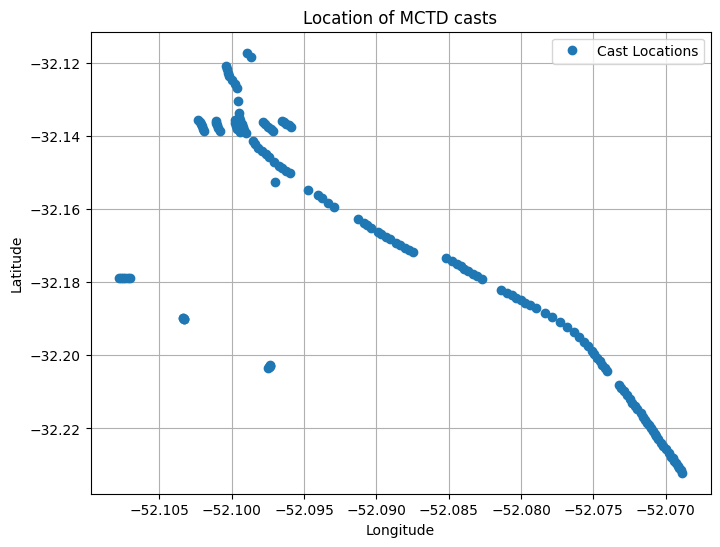

In [15]:
plt.figure(figsize=(8,6))
plt.plot(lon_dat_cast, lat_dat_cast, 'o', label='Cast Locations')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Location of MCTD casts')
plt.grid(True)
plt.legend()

plt.show()

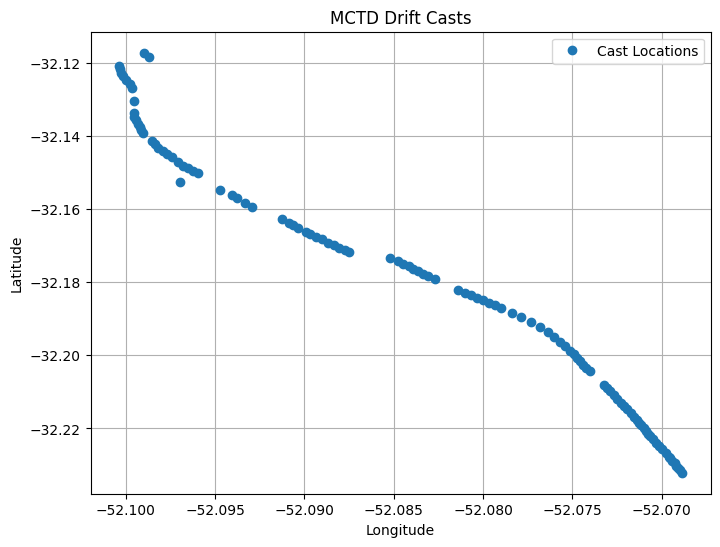

In [16]:
plt.figure(figsize=(8,6))
plt.plot(lon_dat_cast_d, lat_dat_cast_d, 'o', label='Cast Locations')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('MCTD Drift Casts')
plt.grid(True)
plt.legend()

plt.show()

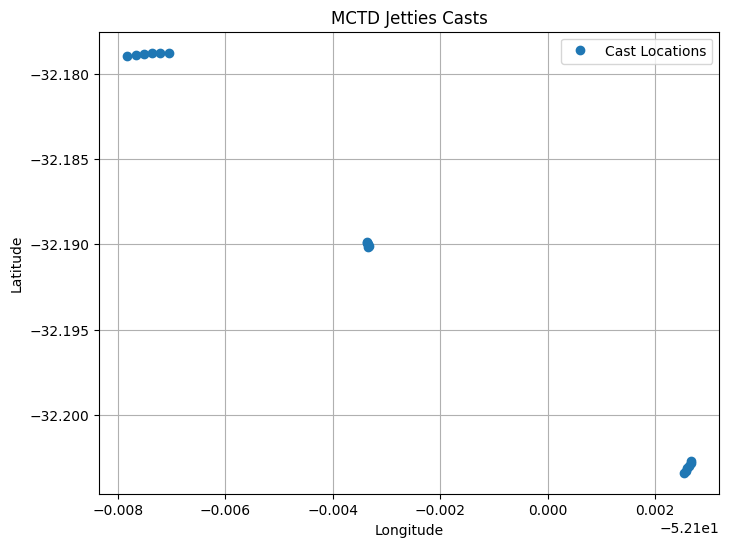

In [17]:
plt.figure(figsize=(8,6))
plt.plot(lon_dat_cast_j, lat_dat_cast_j, 'o', label='Cast Locations')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('MCTD Jetties Casts')
plt.grid(True)
plt.legend()

plt.show()

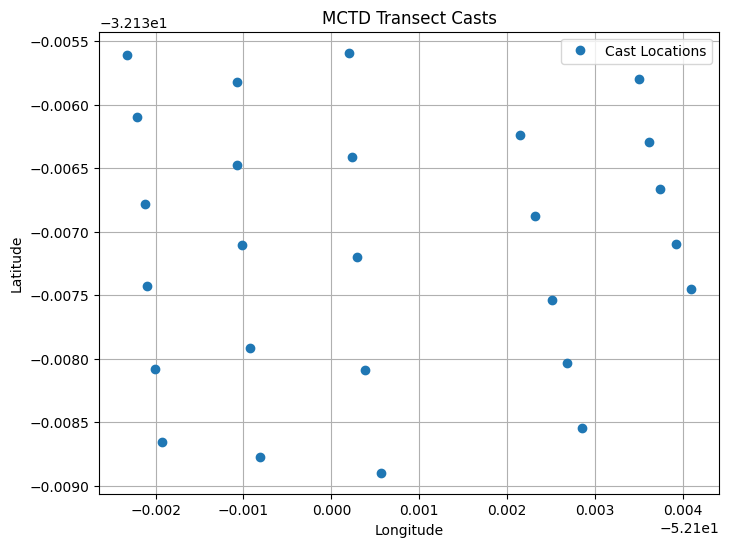

In [18]:
plt.figure(figsize=(8,6))
plt.plot(lon_dat_cast_t, lat_dat_cast_t, 'o', label='Cast Locations')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('MCTD Transect Casts')
plt.grid(True)
plt.legend()

plt.show()

In [19]:
#load the georeferenced map (tif) where you want to plot the casts:

map_path = "/Users/deboragadelha/Jupyter/barros_et_al_2026/input_dir/image_data/"

basemap = rasterio.open(map_path + 'carta2101completa.tif')

sentinelmap = rasterio.open(map_path + 'satelitemap.tiff')


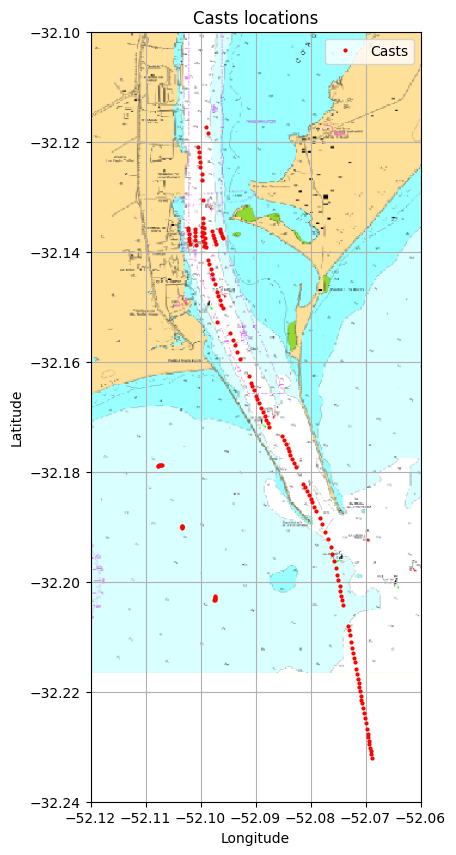

In [20]:
fig, ax = plt.subplots(figsize=(10, 10))  # 🔥 Enlarge the image

# 🔸 Shows the background map
rplot.show(basemap, ax=ax)

# 🔸 Plot the casts
ax.plot(lon_dat_cast, lat_dat_cast, 'ro', ms=2, label='Casts')  # 🔥 smaller dots

# 🔸 Adjust maps limits
ax.set_xlim(-52.12, -52.06)
ax.set_ylim(-32.24, -32.1)

# 🔸 Adjusts labels, grid, title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Casts locations')

# 🔥 🔥 🔥 Save the map
plt.savefig(os.path.join(output_image,'casts_map.png'), dpi=300, bbox_inches='tight')

plt.legend()
plt.grid(True)
plt.show()


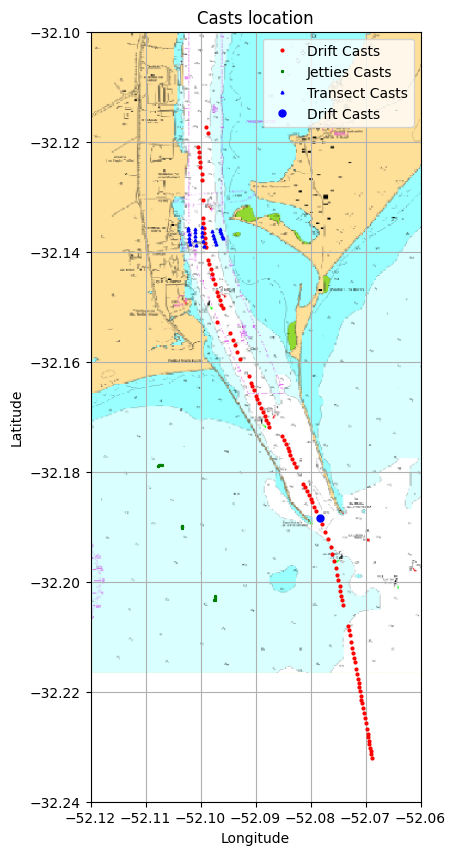

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))  # 🔥 Enlarge the image

# 🔸 shows the background map
rplot.show(basemap, ax=ax)

# 🔸 Plot the casts
ax.plot(lon_dat_cast_d, lat_dat_cast_d, 'ro', ms=2, label='Drift Casts')  # 🔥 smaller dots, red
ax.plot(lon_dat_cast_j, lat_dat_cast_j, 'g*', ms=2, label='Jetties Casts')  # 🔥 smaller stars, green
ax.plot(lon_dat_cast_t, lat_dat_cast_t, 'b^', ms=2, label='Transect Casts')  # 🔥 smaller triangles, blue

ax.plot(lon_dat_cast_d[64], lat_dat_cast_d[64], 'bo', ms=5, label='Drift Casts')  # 🔥 smaller dots, red

# 🔸 Adjust maps limits
ax.set_xlim(-52.12, -52.06)
ax.set_ylim(-32.24, -32.1)

# 🔸 Adjust labels, grid, title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Casts location')


plt.legend()
plt.grid(True)

# 🔥 🔥 🔥 Save the map
plt.savefig(os.path.join(output_image,'casts_detailed_map.png'), dpi=300, bbox_inches='tight')

plt.show()


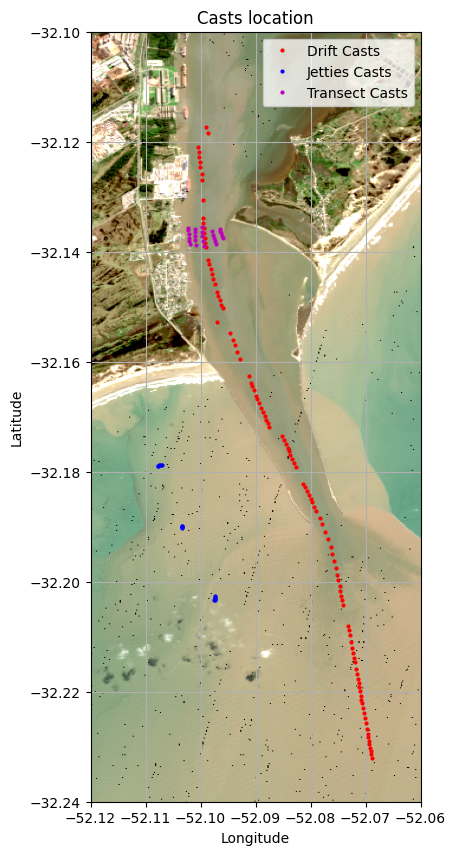

In [22]:
fig, ax = plt.subplots(figsize=(10, 10))  # 🔥 Enlarge the image

# 🔸 shows the background map
rplot.show(sentinelmap, ax=ax)

# 🔸 Plot the casts
ax.plot(lon_dat_cast_d, lat_dat_cast_d, 'ro', ms=2, label='Drift Casts')  # 🔥 smaller dots, red
ax.plot(lon_dat_cast_j, lat_dat_cast_j, 'bo', ms=2, label='Jetties Casts')  # 🔥 smaller stars, green
ax.plot(lon_dat_cast_t, lat_dat_cast_t, 'mo', ms=2, label='Transect Casts')  # 🔥 smaller triangles, blue

#ax.plot(lon_dat_cast_d[64], lat_dat_cast_d[64], 'bo', ms=5, label='Drift Casts')  # 🔥 marcar os molhes

# 🔸 Adjust maps limits
ax.set_xlim(-52.12, -52.06)
ax.set_ylim(-32.24, -32.1)

# 🔸 Adjust labels, grid, title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Casts location')


plt.legend()
plt.grid(True)

# 🔥 🔥 🔥 Save the map
plt.savefig(os.path.join(output_image,'casts_satellitemapzoom.png'), dpi=300, bbox_inches='tight')

plt.show()


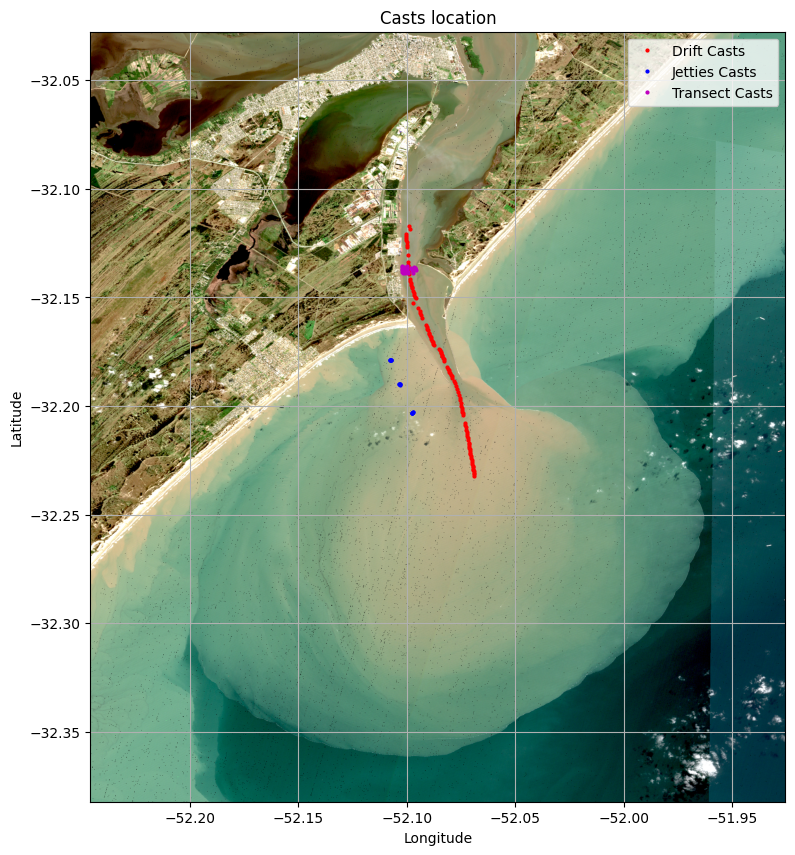

In [23]:
fig, ax = plt.subplots(figsize=(10, 10))  # 🔥 Enlarge the image

# 🔸 shows the background map
rplot.show(sentinelmap, ax=ax)

# 🔸 Plot the casts
ax.plot(lon_dat_cast_d, lat_dat_cast_d, 'ro', ms=2, label='Drift Casts')  # 🔥 smaller dots, red
ax.plot(lon_dat_cast_j, lat_dat_cast_j, 'bo', ms=2, label='Jetties Casts')  # 🔥 smaller stars, green
ax.plot(lon_dat_cast_t, lat_dat_cast_t, 'mo', ms=2, label='Transect Casts')  # 🔥 smaller triangles, blue

#ax.plot(lon_dat_cast_d[64], lat_dat_cast_d[64], 'bo', ms=5, label='Drift Casts')  # 🔥 marcar os molhes

# 🔸 Adjust maps limits
#ax.set_xlim(-52.12, -52.06)
#ax.set_ylim(-32.24, -32.1)

# 🔸 Adjust labels, grid, title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Casts location')


plt.legend()
plt.grid(True)

# 🔥 🔥 🔥 Save the map
plt.savefig(os.path.join(output_image,'casts_satellitemapfull.png'), dpi=300, bbox_inches='tight')

plt.show()


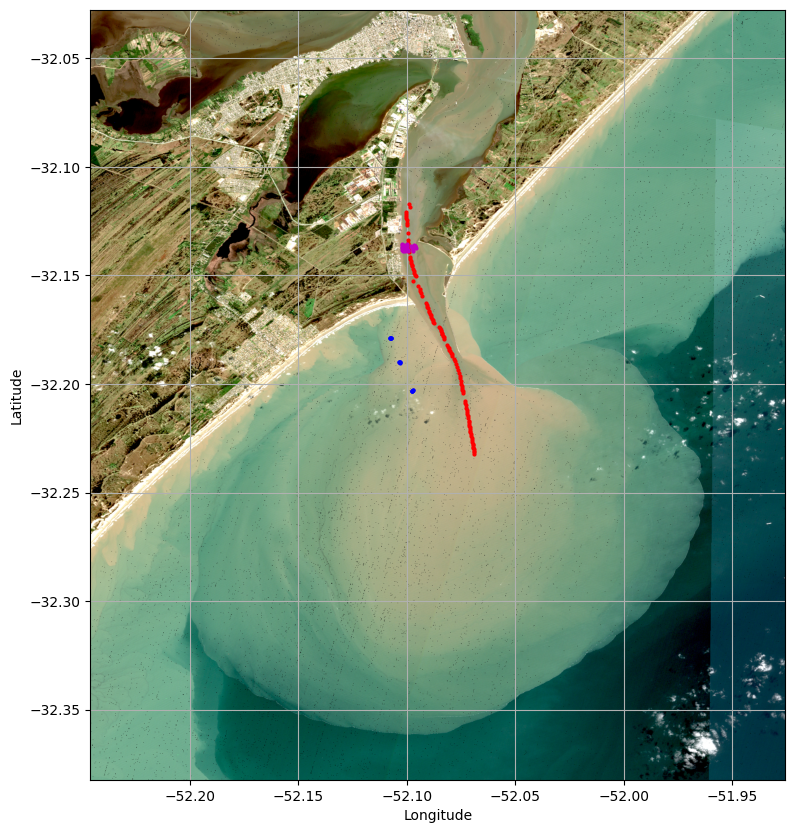

In [26]:
#plotando novamente sem legenda

fig, ax = plt.subplots(figsize=(10, 10))  # 🔥 Enlarge the image

# 🔸 shows the background map
rplot.show(sentinelmap, ax=ax)

# 🔸 Plot the casts
ax.plot(lon_dat_cast_d, lat_dat_cast_d, 'ro', ms=2, label='Drift Casts')  # 🔥 smaller dots, red
ax.plot(lon_dat_cast_j, lat_dat_cast_j, 'bo', ms=2, label='Jetties Casts')  # 🔥 smaller stars, green
ax.plot(lon_dat_cast_t, lat_dat_cast_t, 'mo', ms=2, label='Transect Casts')  # 🔥 smaller triangles, blue

#ax.plot(lon_dat_cast_d[64], lat_dat_cast_d[64], 'bo', ms=5, label='Drift Casts')  # 🔥 marcar os molhes

# 🔸 Adjust maps limits
#ax.set_xlim(-52.12, -52.06)
#ax.set_ylim(-32.24, -32.1)

# 🔸 Adjust labels, grid, title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
#ax.set_title('Casts location')


#plt.legend()
plt.grid(True)

# 🔥 🔥 🔥 Save the map
plt.savefig(os.path.join(output_dir,'casts_satellitemapfull_nolabel.png'), dpi=300, bbox_inches='tight')

plt.show()


In [24]:
# Remove timezone de adcp_time
adcp_time = np.array([t.replace(tzinfo=None) for t in adcp_time])


### **Creating lists of u and v for each profile**  

### **Creating a list with all the variables: ADCP_data**

In [25]:
# Creating the list with all the variables for each profile
ADCP_selectdata = []

# creating the time interval of 30 seconds for each MCTD profile
intervalo = datetime.timedelta(seconds=30)

#creating the u and v list for each MCTD profile
perf_u = []
perf_v = []
perf_depth = []

for i, cast in enumerate(MCTD_time):
    idx = np.array(
        np.where(
            (adcp_time >= cast - intervalo) &
            (adcp_time <= cast + intervalo)
        )
    ).squeeze()

    if idx.size == 0:  # 🚩 check if there is data
        print(f'⚠️ without data for the interval for {cast}')
        perf_u.append(np.full(adcp_u.shape[1], np.nan))
        perf_v.append(np.full(adcp_v.shape[1], np.nan))
        perf_depth.append(np.nan)
        continue

    sel_u = adcp_u[idx, :]
    sel_v = adcp_v[idx, :]
    sel_depth = adcp_depth[idx]
    
    #calculating mean u and v in the time interval of 30 seconds for each MCTD profile
    med_u = np.nanmean(sel_u, axis=0)
    med_v = np.nanmean(sel_v, axis=0)
    med_depth = np.nanmean(sel_depth)

    MCTD_pressure = MCTD_data[i][:,1]
    #problem with diferent adcp_levels and MCTD levels...

    #interpolating the mean u and v for the same level (ADCP x MCTD)
    med_u_i = np.interp(MCTD_pressure, adcp_levels, med_u)
    med_v_i = np.interp(MCTD_pressure, adcp_levels, med_v)
    
    perf_u.append(med_u_i)
    perf_v.append(med_v_i)
    perf_depth.append(med_depth)

    array = MCTD_data[i]
    # Inclui os níveis ADCP também
    new_array = np.vstack((array.T, med_u_i, med_v_i)).T

    ADCP_selectdata.append(new_array)


/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_50042/3468442116.py:32: RuntimeWarning: Mean of empty slice
  med_u = np.nanmean(sel_u, axis=0)
/var/folders/gk/8j_35bvx62ngh8g4pz4f8ykr0000gn/T/ipykernel_50042/3468442116.py:33: RuntimeWarning: Mean of empty slice
  med_v = np.nanmean(sel_v, axis=0)


In [26]:
ADCP_data_drift = ADCP_selectdata[0:109]
ADCP_data_jetties = ADCP_selectdata[109:126]
ADCP_data_transect = ADCP_selectdata[126:]

In [27]:
print(len(ADCP_selectdata))
print(len(ADCP_data_drift))
print(len(ADCP_data_jetties))
print(len(ADCP_data_transect))

152
109
17
26


In [28]:
len(perf_depth)

152

In [29]:
#conferindo o ADCP antes de interpolar:
for i in range(1, 150):
    print(f"  ADCP prof max: {np.max(perf_depth[i]):.2f}")

  ADCP prof max: 14.12
  ADCP prof max: 16.45
  ADCP prof max: 16.82
  ADCP prof max: 17.06
  ADCP prof max: 17.24
  ADCP prof max: 17.31
  ADCP prof max: 17.31
  ADCP prof max: 17.17
  ADCP prof max: 16.71
  ADCP prof max: 15.86
  ADCP prof max: 15.64
  ADCP prof max: 15.50
  ADCP prof max: 15.26
  ADCP prof max: 15.10
  ADCP prof max: 14.96
  ADCP prof max: 14.84
  ADCP prof max: 14.52
  ADCP prof max: 14.49
  ADCP prof max: 14.44
  ADCP prof max: 14.43
  ADCP prof max: 14.41
  ADCP prof max: 14.38
  ADCP prof max: 14.37
  ADCP prof max: 14.33
  ADCP prof max: 14.30
  ADCP prof max: 14.29
  ADCP prof max: 14.21
  ADCP prof max: 14.27
  ADCP prof max: 14.36
  ADCP prof max: 14.23
  ADCP prof max: 14.22
  ADCP prof max: 14.13
  ADCP prof max: 13.84
  ADCP prof max: 14.05
  ADCP prof max: 14.01
  ADCP prof max: 14.00
  ADCP prof max: 14.07
  ADCP prof max: 14.07
  ADCP prof max: 14.02
  ADCP prof max: 14.02
  ADCP prof max: 13.97
  ADCP prof max: 13.80
  ADCP prof max: 13.69
  ADCP prof

In [33]:
#generates a file containing all the variables for the profiles: 

# Save the pickle on the right folder:

with open(os.path.join(output_data,'ADCP_selectdata.pkl'), 'wb') as io:
    pickle.dump(ADCP_selectdata, io)
    
with open(os.path.join(output_data,'ADCP_data_drift.pkl'), 'wb') as io:
    pickle.dump(ADCP_data_drift, io)

with open(os.path.join(output_data,'ADCP_data_jetties.pkl'), 'wb') as io:
    pickle.dump(ADCP_data_jetties, io)

with open(os.path.join(output_data,'ADCP_data_transect.pkl'), 'wb') as io:
    pickle.dump(ADCP_data_transect, io)

with open(os.path.join(output_data,'perf_adcp_depth.pkl'), 'wb') as io:
    pickle.dump(perf_depth, io)



# (Opcional) salvar os dados com pickle

#with open('perf_u.pkl', 'wb') as f:
   # pickle.dump(perf_u, f)

#with open('perf_v.pkl', 'wb') as f:
   # pickle.dump(perf_v, f)


In [34]:
#calculating dz (which will be the same for all the casts) to use on STEP5:
dz = (adcp_levels[0] - adcp_levels[1]) * -1
dz

np.float64(0.25)

In [35]:
# Converting from list to array
perf_depth = np.array(perf_depth)  # shape: (n_perfis,)

# Slicing with the previous index:
depth_drift = perf_depth[0:109]
depth_jetties = perf_depth[109:126]
depth_transect = perf_depth[126:]

# dictionary
depths = {
    'drift': depth_drift,
    'jetties': depth_jetties,
    'transect': depth_transect
}

# Saving pickle
with open('../processed_data/bottom_ADCP_depths.pkl', 'wb') as f:
    pickle.dump(depths, f)

print("✅ bottom_ADCP_depths.pkl saved.")


✅ bottom_ADCP_depths.pkl saved.


<span style="color:red">This code was last tested on February 13, 2026, and is running without issues.</span>


## END OF CODE